In [ ]:
from __future__ import division, print_function
import bilby
from gwpy.timeseries import TimeSeries
import math
from bilby.gw.conversion import component_masses_to_chirp_mass, component_masses_to_symmetric_mass_ratio, luminosity_distance_to_redshift, chirp_mass_and_mass_ratio_to_component_masses
from bilby.core import utils
import numpy as np
from gwosc import datasets
from astropy import constants as const
import sys
import argparse
import configparser
import os
import errno
import json
import datetime
import scipy.signal.windows as windows
import matplotlib.pyplot as plt
from bilby.core.utils import infft

"""get current time"""
start = datetime.datetime.now()

"""constants"""
Mo = const.M_sun.value #solar mass [kg]
G = const.G.value #Newton constant [m^3 kg^-1 s^2]
c = const.c.value #light speed [m s^-1]
pc = const.pc.value #1pc [m]

plt.style.use('~/research/my_plot_style.style')

"""get ringdown waveform from config file"""
def get_ringdown_waveform_from_config(config_file_path, signal_roll_on_duration_list=[0.01]):

    config_path = config_file_path
    config_ini = configparser.ConfigParser()
    config_ini.read(config_path)

    config_setting = config_ini['setting']
    config_injection = config_ini['injection_parameters']
    config_wf_args = config_ini['waveform_arguments']
    config_others = config_ini['other_parameters']

    """set the event to be analyzed"""
    event_name = config_setting['event_name']
    outdir_path = config_setting['outdir_path']
    outdir = outdir_path + 'outdir_' + event_name
    label = event_name
    logger = bilby.core.utils.logger
    bilby.core.utils.setup_logger(outdir=outdir, label=label)

    """output to .log file"""
    comment = config_setting['comment']
    bilby.core.utils.logger.info(comment.replace('_', ' '))
    bilby.core.utils.logger.info('event_name : '+event_name)

    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('mode_number : '+mode_number)

    """parameterization"""
    parameterization = config_setting['parameterization']
    bilby.core.utils.logger.info('parameterization : '+parameterization)

    """mode number"""
    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('one_mode : '+str(one_mode))

    analysis_one_mode = False
    analysis_mode_number = config_setting['analysis_mode_number']
    if analysis_mode_number=='analysis_one_mode':
        analysis_one_mode = True
    bilby.core.utils.logger.info('analysis_one_mode : '+str(analysis_one_mode))

    """output waveform args"""
    for key in config_wf_args.keys():
        bilby.core.utils.logger.info('{0} : {1}'.format(key, config_wf_args[key]))

    """waveform"""
    def toy_model_of_two_QNMs(time, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time, window_alpha=0.1, signal_roll_on_duration=0.01):
        """
        Returns
        -------
        dict:
            A dictionary containing "plus" and "cross" entries.
        """
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A * (1 + delta_w * alpha) / delta_w * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)
        
        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), window_alpha)  # Tukey window with alpha=window_alpha

        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window
        return {"plus": plus, "cross": cross}

    def get_each_overtone(time, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time, window_alpha=0.1, signal_roll_on_duration=0.01):
        """
        Returns
        -------
        dict:
            A dictionary containing "waveform1", "waveform2", and "plus" entries.
        """
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-20
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A * (1 + delta_w * alpha) / delta_w * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)
        

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        waveform1[start_index:taper_end_index] *= hann_taper
        waveform2[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), window_alpha)  # Tukey window with alpha=window_alpha
        waveform1 *= tukey_window
        waveform2 *= tukey_window

        plus = (waveform1 + waveform2).real * tukey_window
        return {"waveform1": waveform1, "waveform2": waveform2, "plus": plus}
    
    def damped_sinusoid(time, A1, A2, f1, deltaf, tau1, tau2, phi1, phi2, geocent_time, window_alpha=0.1, signal_roll_on_duration=0.01):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        f2 = f1 + deltaf
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        plus = (waveform1 + waveform2).real
        cross = (waveform1 + waveform2).imag

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        plus[start_index:taper_end_index] *= hann_taper
        cross[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), window_alpha)  # Tukey window with alpha=window_alpha
        plus *= tukey_window
        cross *= tukey_window

        return {"plus": plus, "cross": cross}

    def get_each_overtone_as_damped_sinusoid_parameters(time, A1, A2, f1, deltaf, tau1, tau2, phi1, phi2, geocent_time, window_alpha=0.1, signal_roll_on_duration=0.01):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        f2 = f1 + deltaf
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index
        
        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        waveform1[start_index:taper_end_index] *= hann_taper
        waveform2[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), window_alpha)  # Tukey window with alpha=window_alpha
        waveform1 *= tukey_window
        waveform2 *= tukey_window

        plus = (waveform1 + waveform2).real * tukey_window
        return {"waveform1": waveform1, "waveform2": waveform2, "plus": plus}

    """set parameters"""
    duration = float(config_others['duration'])
    sampling_frequency = float(config_others['sampling_frequency'])
    trigger_time = float(config_injection['geocent_time'])
    post_trigger_duration = float(config_others['post_trigger_duration'])
    start_time = trigger_time - duration + post_trigger_duration
    bilby.core.utils.logger.info('duration : {}'.format(duration))
    bilby.core.utils.logger.info('sampling frequency : {}'.format(sampling_frequency))
    bilby.core.utils.logger.info('trigger time : {}'.format(trigger_time))
    bilby.core.utils.logger.info('start time : {}'.format(start_time))

    
    """set injection parameters and waveform generator"""
    waveform_tdomain_list = []
    waveform_fdomain_list = []
    waveform_overtone_tdomain_list = []
    waveform_overtone_fdomain_list = []
    window_alpha = 0.1
    for signal_roll_on_duration in signal_roll_on_duration_list:
        bilby.core.utils.logger.info('signal_roll_on_duration : {}'.format(signal_roll_on_duration))
    
        if parameterization == 'DS':
            A = float(config_injection['A']) * 1e-20  # Convert to strain unit
            alpha = float(config_injection['alpha'])
            w1 = (2 * np.pi * float(config_injection['f1']) + 1j / float(config_injection['tau1']))
            w2 = (2 * np.pi * float(config_injection['f2']) + 1j / float(config_injection['tau2']))
            delta_w = w2 - w1
            A1_complex = A / delta_w
            A1 = np.abs(A1_complex) / 1e-20
            phi1_from_amp = np.angle(A1_complex)
            phi1 = float(config_injection['phi1']) + phi1_from_amp
            A2_complex = - A * (1 + alpha * delta_w) / delta_w
            A2 = np.abs(A2_complex) / 1e-20
            phi2_from_amp = np.angle(A2_complex)
            phi2 = float(config_injection['phi2']) + phi2_from_amp
            bilby.core.utils.logger.info('A1 : {}'.format(A1))
            bilby.core.utils.logger.info('A2 : {}'.format(A2))
            bilby.core.utils.logger.info('alpha : {}'.format(alpha))
            bilby.core.utils.logger.info('w1 : {}'.format(w1))
            bilby.core.utils.logger.info('w2 : {}'.format(w2))
            bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
            bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
            bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
            bilby.core.utils.logger.info('phi2 : {}'.format(phi2))
            injection_parameters = dict(
                                        A1 = A1 * 1e-1,
                                        A2 = A2 * 1e-1,
                                        f1 = float(config_injection['f1']),
                                        # f2 = float(config_injection['f2']),
                                        deltaf = float(config_injection['f2']) - float(config_injection['f1']),
                                        tau1 = float(config_injection['tau1']),
                                        tau2 = float(config_injection['tau2']),
                                        phi1 = phi1,
                                        phi2 = phi2,
                                        ra = float(config_injection['ra']),
                                        dec = float(config_injection['dec']),
                                        psi = float(config_injection['psi']),
                                        geocent_time = float(config_injection['geocent_time']),
                                        window_alpha = window_alpha,
                                        signal_roll_on_duration = signal_roll_on_duration,
                                        )

            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    time_domain_source_model = damped_sinusoid,
                                    start_time = start_time,
                                    )

        if parameterization == 'OT':
            injection_parameters = dict(
                                        A = float(config_injection['A']) * 1e-3,
                                        alpha = float(config_injection['alpha']),
                                        f1 = float(config_injection['f1']),
                                        tau1 = float(config_injection['tau1']),
                                        f2 = float(config_injection['f2']),
                                        tau2 = float(config_injection['tau2']),
                                        phi1 = float(config_injection['phi1']),
                                        phi2 = float(config_injection['phi2']),
                                        ra = float(config_injection['ra']),
                                        dec = float(config_injection['dec']),
                                        psi = float(config_injection['psi']),
                                        geocent_time = float(config_injection['geocent_time']),
                                        window_alpha = window_alpha,
                                        signal_roll_on_duration = signal_roll_on_duration,
                                        )

            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                    duration = duration,
                                    sampling_frequency = sampling_frequency,
                                    time_domain_source_model = toy_model_of_two_QNMs,
                                    start_time = start_time,
                                    )

        """set interferometers"""
        ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1'])
        #ifos.set_strain_data_from_zero_noise(
        #                                sampling_frequency = sampling_frequency,
        #                                duration = duration,
        #                                start_time = start_time
        #                                )

        ifos.set_strain_data_from_power_spectral_densities(
                                        sampling_frequency = sampling_frequency,
                                        duration = duration,
                                        start_time = start_time
                                        )
        for interferometer in ifos:
            interferometer.minimum_frequency = float(config_wf_args['minimum_frequency'])
            interferometer.maximum_frequency = float(config_wf_args['maximum_frequency'])
        """inject signal"""
        ifos.inject_signal(
            waveform_generator=waveform_generator,
            parameters=injection_parameters,
            raise_error=False
        )

        t_array = waveform_generator.time_array
        t_domain = waveform_generator.time_domain_strain(injection_parameters)
        f_array = waveform_generator.frequency_array
        f_domain = waveform_generator.frequency_domain_strain(injection_parameters)
        waveform_tdomain_list.append([t_array, t_domain])
        waveform_fdomain_list.append([f_array, f_domain])

        if parameterization == 'DS':
            waveform_generator_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                time_domain_source_model = get_each_overtone_as_damped_sinusoid_parameters,
                                start_time = start_time,
                                )
        
        if parameterization == 'OT':
            waveform_generator_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                time_domain_source_model = get_each_overtone,
                                start_time = start_time,
                                )
        t_array = waveform_generator_overtone.time_array
        ht_overtone = waveform_generator_overtone.time_domain_strain(injection_parameters)
        f_array = waveform_generator_overtone.frequency_array
        hf_overtone = waveform_generator_overtone.frequency_domain_strain(injection_parameters)

        waveform_overtone_tdomain_list.append([ht_overtone, t_array])
        waveform_overtone_fdomain_list.append([hf_overtone, f_array])

    # """print fractional defference of the frequencies"""
    # w1_real = 2 * np.pi * injection_parameters['f1']
    # w1_imag = 1 / injection_parameters['tau1']
    # w2_real = 2 * np.pi * float(config_injection['f2'])
    # w2_imag = 1 / injection_parameters['tau2']
    # w1 = w1_real + 1j * w1_imag
    # w2 = w2_real + 1j * w2_imag
    # delta_w = w2 - w1
    # delta_w_real = delta_w.real
    # delta_w_imag = delta_w.imag
    # print('--------------------------------')
    # print(f'mode_number = {mode_number}')
    # print('w1 = {} + i*{}'.format(w1_real, w1_imag))
    # print('w2 = {} + i*{}'.format(w2_real, w2_imag))
    # print('delta_w = w2 - w1 = {} + i*{}'.format(delta_w.real, delta_w.imag))
    # print('Re[delta_w] / Re[w1] = {}'.format(delta_w_real / w1_real))
    # print('Im[delta_w] / Im[w1] = {}'.format(delta_w_imag / w1_imag))
    # print('|delta_w| = {}'.format(np.abs(delta_w)))
    # print('|delta_w| / |w1| = {}'.format(np.abs(delta_w) / np.abs(w1)))
    # print('A / |delta_w| = {}'.format(float(config_injection['A']) / np.abs(delta_w)))
    # print('--------------------------------')
    # print()
    # """"""

        """print SNR"""
        hf_plus_dict = {}
        hf_plus_dict['plus'] = waveform_generator.frequency_domain_strain(injection_parameters)['plus']
        hf_cross_dict = {}
        hf_cross_dict['cross'] = waveform_generator.frequency_domain_strain(injection_parameters)['cross']

        SNR_plus = np.zeros(len(ifos))
        SNR_cross = np.zeros(len(ifos))
        for num, ifo in enumerate(ifos):
            hf_det_plus = ifo.get_detector_response(hf_plus_dict, injection_parameters)
            hf_det_cross = ifo.get_detector_response(hf_cross_dict, injection_parameters)
            SNR_plus[num] = np.sqrt(ifo.optimal_snr_squared(signal=hf_det_plus).real)
            SNR_cross[num] = np.sqrt(ifo.optimal_snr_squared(signal=hf_det_cross).real)
        print('--------------------------------')
        print('SNR of only plus mode : {}'.format(SNR_plus))
        print('network SNR of only plus mode : {}'.format(np.sum(SNR_plus**2.)**0.5))
        print('SNR of only cross mode : {}'.format(SNR_cross))
        print('network SNR of only cross mode : {}'.format(np.sum(SNR_cross**2.)**0.5))
        print('--------------------------------')
        print()

        hf_det_snr = np.zeros((len(ifos), len(ifos[0].strain_data.frequency_domain_strain)), dtype=complex)
        SNR = np.zeros(len(ifos))
        for num, ifo in enumerate(ifos):
            hf_det_snr[num] = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters), injection_parameters)
            SNR[num] = np.sqrt(np.real(ifo.optimal_snr_squared(hf_det_snr[num])))
        network_SNR = np.sqrt(np.sum(SNR**2.))
        print('--------------------------------')
        print('SNR : {}'.format(SNR))
        print('network SNR : {}'.format(network_SNR))
        print('--------------------------------')
        """"""

    plot_start = trigger_time - duration/20
    plot_end = trigger_time + duration/10
    """plot waveform time domain"""
    plt.figure()
    for _signal_roll_on_duration, _waveform_tdomain in zip(signal_roll_on_duration_list, waveform_tdomain_list):
        t_array = _waveform_tdomain[0]
        ht_plus = _waveform_tdomain[1]['plus']
        ht_cross = _waveform_tdomain[1]['cross']
        plt.plot(t_array, ht_plus, label=r"$h_+, dt={}$".format(_signal_roll_on_duration))
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Strain")
    # plt.xlim(start_time, start_time + duration)
    plt.xlim(plot_start, plot_end)
    # plt.title("Injected Strain")
    plt.grid()
    plt.show()
    #
    plt.figure()
    for _signal_roll_on_duration, _waveform_tdomain in zip(signal_roll_on_duration_list, waveform_tdomain_list):
        t_array = _waveform_tdomain[0]
        ht_cross = _waveform_tdomain[1]['cross']
        plt.plot(t_array, ht_cross, label=r"$h_\times, dt={}$".format(_signal_roll_on_duration), ls='--')
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Strain")
    # plt.xlim(start_time, start_time + duration)
    plt.xlim(plot_start, plot_end)
    # plt.title("Injected Strain")
    plt.grid()
    plt.show()
    """"""

    """plot waveform frequency domain"""
    plt.figure()
    for _signal_roll_on_duration, _waveform_fdomain in zip(signal_roll_on_duration_list, waveform_fdomain_list):
        f_array = _waveform_fdomain[0]
        hf_plus = _waveform_fdomain[1]['plus']
        hf_cross = _waveform_fdomain[1]['cross']
        plt.plot(f_array, np.abs(hf_plus), label=r"$|h_+|, dt={}$".format(_signal_roll_on_duration))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    # plt.title("Injected Frequency Domain Strain")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()
    #
    plt.figure()
    for _signal_roll_on_duration, _waveform_fdomain in zip(signal_roll_on_duration_list, waveform_fdomain_list):
        f_array = _waveform_fdomain[0]
        hf_cross = _waveform_fdomain[1]['cross']
        plt.plot(f_array, np.abs(hf_cross), label=r"$|h_\times|, dt={}$".format(_signal_roll_on_duration), ls='--')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    # plt.title("Injected Frequency Domain Strain")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()
    #
    plt.figure()
    for _signal_roll_on_duration, _waveform_fdomain in zip(signal_roll_on_duration_list, waveform_fdomain_list):
        f_array = _waveform_fdomain[0]
        hf_cross = _waveform_fdomain[1]['cross']
        plt.plot(f_array, np.abs(hf_cross), label=r"$|h_\times|, dt={}$".format(_signal_roll_on_duration), ls='--')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    # plt.title("Injected Frequency Domain Strain")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()
    """"""

    """plot overtone"""
    # plt.figure()
    # for _signal_roll_on_duration, _waveform_overtone_tdomain in zip(signal_roll_on_duration_list, waveform_overtone_tdomain_list):
    #     t_array = _waveform_overtone_tdomain[1]
    #     ht_overtone = _waveform_overtone_tdomain[0]
    #     plt.plot(t_array, ht_overtone['plus'].real, label=r"$h_+(t)$, dt={}".format(_signal_roll_on_duration), color='black')
    #     plt.plot(t_array, ht_overtone['waveform1'].real, label=r"$h_1(t)$, dt={}".format(_signal_roll_on_duration), ls='--', alpha=0.7)
    #     plt.plot(t_array, ht_overtone['waveform2'].real, label=r"$h_2(t)$, dt={}".format(_signal_roll_on_duration), ls='--', alpha=0.7)
    # plt.xlabel("Time (s)")
    # plt.ylabel("Strain")
    # # plt.xlim(start_time, start_time + duration)
    # plt.xlim(plot_start, plot_end)
    # # plt.ylim(-1e-21, 1e-21)
    # plt.title("Injected Time Domain Strain Signal with Overtones")
    # plt.grid()
    # plt.legend()
    # plt.show()
    """"""

    """plot waveform frequency domain"""
    # plt.figure()
    # for _signal_roll_on_duration, _waveform_overtone_fdomain in zip(signal_roll_on_duration_list, waveform_overtone_fdomain_list):
    #     f_array = _waveform_overtone_fdomain[1]
    #     hf_overtone = _waveform_overtone_fdomain[0]
    #     hf_overtone_plus = hf_overtone['plus']
    #     hf_overtone_waveform1 = hf_overtone['waveform1']
    #     hf_overtone_waveform2 = hf_overtone['waveform2']
    #     plt.plot(f_array, np.abs(hf_overtone_plus), label=r"$|h_+|, dt={}$".format(_signal_roll_on_duration), color='black')
    #     plt.plot(f_array, np.abs(hf_overtone_waveform1), label=r"$|h_1|, dt={}$".format(_signal_roll_on_duration), ls='--', alpha=0.7)
    #     plt.plot(f_array, np.abs(hf_overtone_waveform2), label=r"$|h_2|, dt={}$".format(_signal_roll_on_duration), ls='--', alpha=0.7)
    # plt.xlabel("Frequency (Hz)")
    # plt.ylabel("Strain")
    # plt.title("Injected Frequency Domain Strain Signal")
    # plt.xscale("log")
    # plt.yscale("log")
    # plt.grid()
    # plt.legend()
    # plt.show()
    """"""

/Users/hayato/research/env/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


13:18 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, damped sinusoid parameterization
13:18 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_DSparam_v2
13:18 bilby INFO    : mode_number : two_mode
13:18 bilby INFO    : parameterization : DS
13:18 bilby INFO    : one_mode : False
13:18 bilby INFO    : analysis_one_mode : False
13:18 bilby INFO    : minimum_frequency : 20
13:18 bilby INFO    : maximum_frequency : 512
13:18 bilby INFO    : duration : 0.5
13:18 bilby INFO    : sampling frequency : 4096.0
13:18 bilby INFO    : trigger time : 0.0
13:18 bilby INFO    : start time : -0.25
13:18 bilby INFO    : signal_roll_on_duration : 0.0
13:18 bilby INFO    : A1 : 2.281200654005359
13:18 bilby INFO    : A2 : 2.193576170046821
13:18 bilby INFO    : alpha : 0.00029552945685847607
13:18 bilby INFO    : w1 : (1264.4143462793452-301.02689574732483j)
13:18 bilby INFO    : w2 : (1134.4389320257144-301.02689574732483j)
13:18 bilby INFO    : delta_w : (-129.9754142

--------------------------------
SNR of only plus mode : [32.29963484 51.73290466  3.1075553 ]
network SNR of only plus mode : 61.06731314605789
SNR of only cross mode : [49.96463076 47.96544482 38.32139884]
network SNR of only cross mode : 79.15603472122115
--------------------------------

--------------------------------
SNR : [59.55101195 70.6194975  38.44227161]
network SNR : 100.05620770005973
--------------------------------
--------------------------------
SNR of only plus mode : [32.09803773 51.41001543  3.08439735]
network SNR of only plus mode : 60.68597217804441
SNR of only cross mode : [49.44762085 47.46912152 37.90060252]
network SNR of only cross mode : 78.32522184884616
--------------------------------

--------------------------------
SNR : [58.79507303 69.77016949 38.04948585]
network SNR : 98.85595853130786
--------------------------------
--------------------------------
SNR of only plus mode : [31.48654008 50.43060655  3.02781284]
network SNR of only plus mode : 59

13:18 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
13:18 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
13:18 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
13:18 bilby INFO    : Injected signal in H1:
13:18 bilby INFO    :   optimal SNR = 52.77
13:18 bilby INFO    :   matched filter SNR = 52.46-0.80j
13:18 bilby INFO    :   A1 = 0.2281200654005359
13:18 bilby INFO    :   A2 = 0.2193576170046821
13:18 bilby INFO    :   f1 = 201.23779332666524
13:18 bilby INFO    :   deltaf = -20.686229658882155
13:18 bilby INFO    :   tau1 = -0.0033219623034593474
13:18 bilby INFO    :   tau2 = -0.0033219623034593474
13:18 bilby INFO    :   phi1 = -3.141592653589793
13:18 bilby INFO    :   phi2 = 0.0
13:18 bilby INFO    :   ra = 0.0
13:18 bilby INFO    :   dec = 0.0
13:18 bilby INFO    :   psi = 0.0
13:18 bilby INFO    :   geocent_time = 0.0
13:18 bilby INFO    :   window_alpha = 0.1
13:18 bilby 

--------------------------------
SNR of only plus mode : [28.52090005 45.68067133  2.74223445]
network SNR of only plus mode : 53.92295728576261
SNR of only cross mode : [44.79343101 43.00115523 34.32296318]
network SNR of only cross mode : 70.94798527117612
--------------------------------

--------------------------------
SNR : [52.76875026 62.30141722 34.46812386]
network SNR : 88.62312990370738
--------------------------------
--------------------------------
SNR of only plus mode : [26.99269326 43.23300972  2.59609629]
network SNR of only plus mode : 51.03369803080346
SNR of only cross mode : [41.80277877 40.13016504 32.04147597]
network SNR of only cross mode : 66.2159998919749
--------------------------------

--------------------------------
SNR : [49.757165   58.9835436  32.14664758]
network SNR : 83.5956986617907
--------------------------------


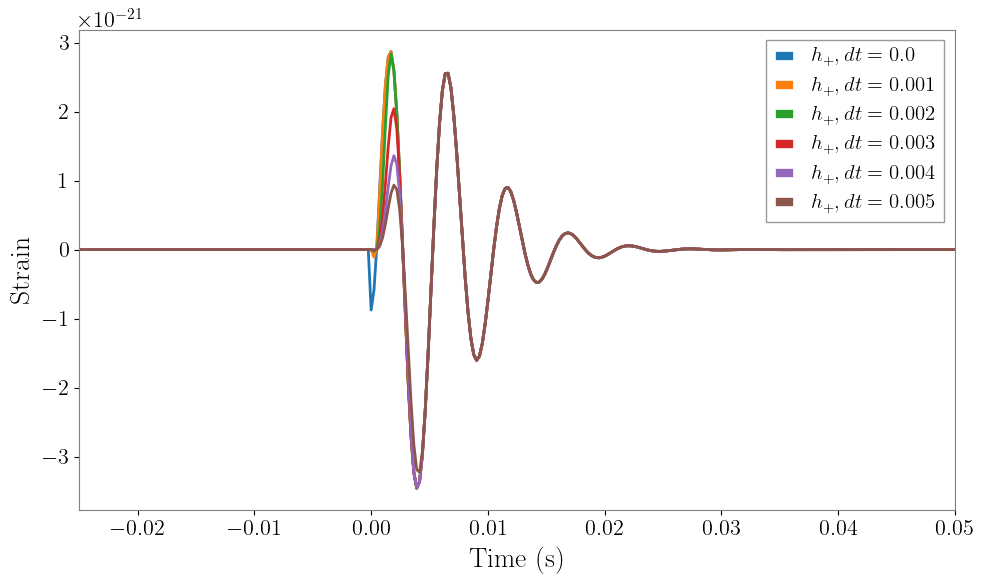

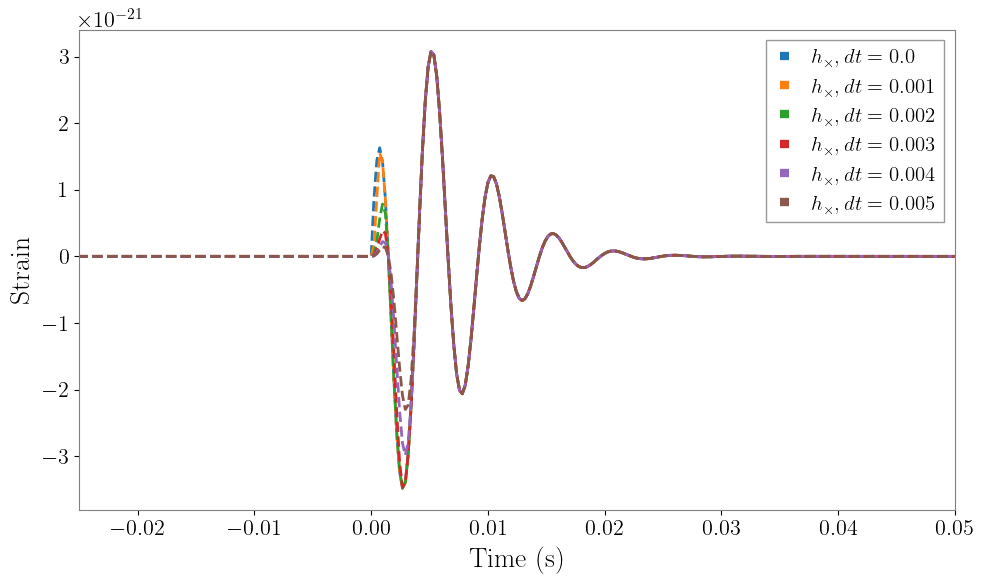

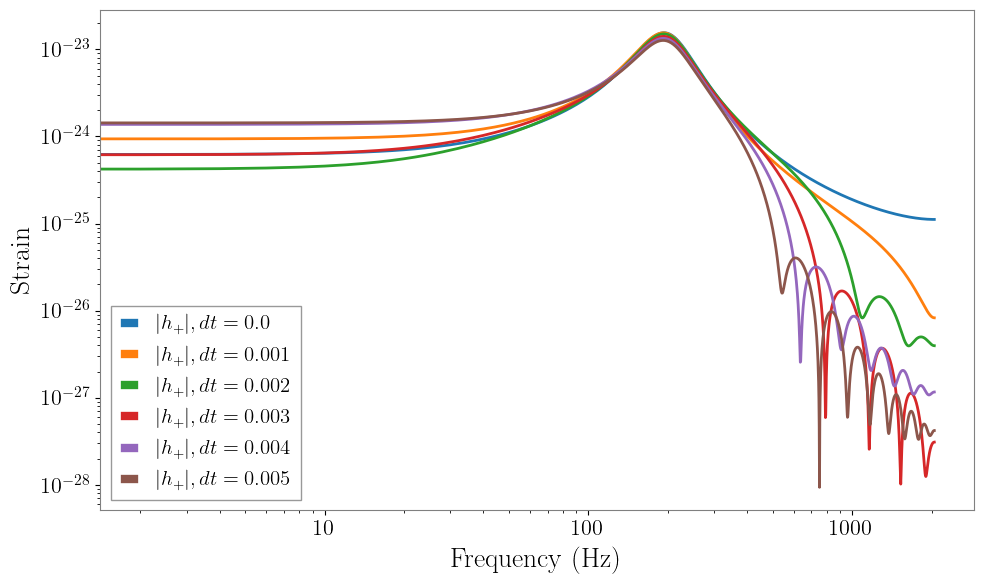

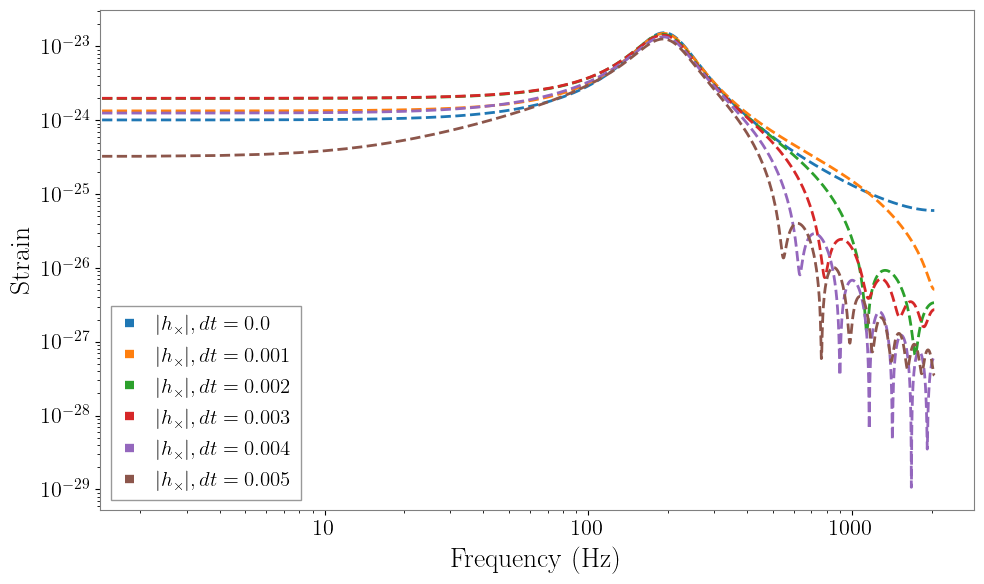

In [4]:
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam.ini'

signal_roll_on_duration_list = np.arange(0.0, 0.00501, 0.001).tolist()
get_ringdown_waveform_from_config(config_path, signal_roll_on_duration_list=signal_roll_on_duration_list)

14:46 bilby INFO    : shift imaginary part of w to 220 with spin0, dw/w0.1, snr100, damped sinusoid parameterization
14:46 bilby INFO    : event_name : shiftIm_to_220_dw0.1w1_snr100_DSparam_v2
14:46 bilby INFO    : mode_number : two_mode
14:46 bilby INFO    : parameterization : DS
14:46 bilby INFO    : one_mode : False
14:46 bilby INFO    : analysis_one_mode : False
14:46 bilby INFO    : minimum_frequency : 20
14:46 bilby INFO    : maximum_frequency : 512
14:46 bilby INFO    : duration : 0.5
14:46 bilby INFO    : sampling frequency : 4096.0
14:46 bilby INFO    : trigger time : 0.0
14:46 bilby INFO    : start time : -0.25
14:46 bilby INFO    : signal_roll_on_duration : 0.0
14:46 bilby INFO    : A1 : 2.8543859785362136
14:46 bilby INFO    : A2 : 2.8564909517284405
14:46 bilby INFO    : alpha : 0.00029552945685847607
14:46 bilby INFO    : w1 : (1264.4143462793452-301.02689574732483j)
14:46 bilby INFO    : w2 : (1264.4143462793452-431.00231000095573j)
14:46 bilby INFO    : delta_w : -129.9

--------------------------------
SNR of only plus mode : [32.30595857 51.7430331   3.1360668 ]
network SNR of only plus mode : 61.08069538687955
SNR of only cross mode : [49.83976876 47.84557881 38.57039691]
network SNR of only cross mode : 79.12570681691236
--------------------------------

--------------------------------
SNR : [59.47519821 70.57857264 38.68959388]
network SNR : 100.07756387909089
--------------------------------
--------------------------------
SNR of only plus mode : [31.06018123 49.74772632  3.01270556]
network SNR of only plus mode : 58.725186474503154
SNR of only cross mode : [47.67688537 45.76923675 36.7792779 ]
network SNR of only cross mode : 75.6348049080137
--------------------------------

--------------------------------
SNR : [57.67126242 68.59448    36.81865081]
network SNR : 96.88544907666905
--------------------------------
--------------------------------
SNR of only plus mode : [27.3795342  43.85259584  2.6549611 ]
network SNR of only plus mode : 51

14:46 bilby INFO    :   tau1 = -0.0033219623034593474
14:46 bilby INFO    :   tau2 = -0.0023201731795771175
14:46 bilby INFO    :   phi1 = 1.5707963267948966
14:46 bilby INFO    :   phi2 = -1.6091890156562867
14:46 bilby INFO    :   ra = 0.0
14:46 bilby INFO    :   dec = 0.0
14:46 bilby INFO    :   psi = 0.0
14:46 bilby INFO    :   geocent_time = 0.0
14:46 bilby INFO    :   window_alpha = 0.1
14:46 bilby INFO    :   signal_roll_on_duration = 0.008
14:46 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
14:46 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
14:46 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
14:46 bilby INFO    : Injected signal in L1:
14:46 bilby INFO    :   optimal SNR = 42.03
14:46 bilby INFO    :   matched filter SNR = 41.16-0.82j
14:46 bilby INFO    :   A1 = 0.28543859785362136
14:46 bilby INFO    :   A2 = 0.28564909517284404
14:46 bilby INFO    :   f1 = 201.237793

--------------------------------
SNR of only plus mode : [19.16269534 30.6920464   1.85916781]
network SNR of only plus mode : 36.230748129751554
SNR of only cross mode : [29.8761351  28.6807305  23.10231317]
network SNR of only cross mode : 47.4224063518637
--------------------------------

--------------------------------
SNR : [35.5079443  42.02567136 23.17520989]
network SNR : 59.699761431777326
--------------------------------
--------------------------------
SNR of only plus mode : [15.6975325  25.14204746  1.5216941 ]
network SNR of only plus mode : 29.67912785368926
SNR of only cross mode : [24.45902651 23.48037139 18.89783961]
network SNR of only cross mode : 38.81623577755876
--------------------------------

--------------------------------
SNR : [29.06167976 34.39963157 18.95900681]
network SNR : 48.86061626843233
--------------------------------


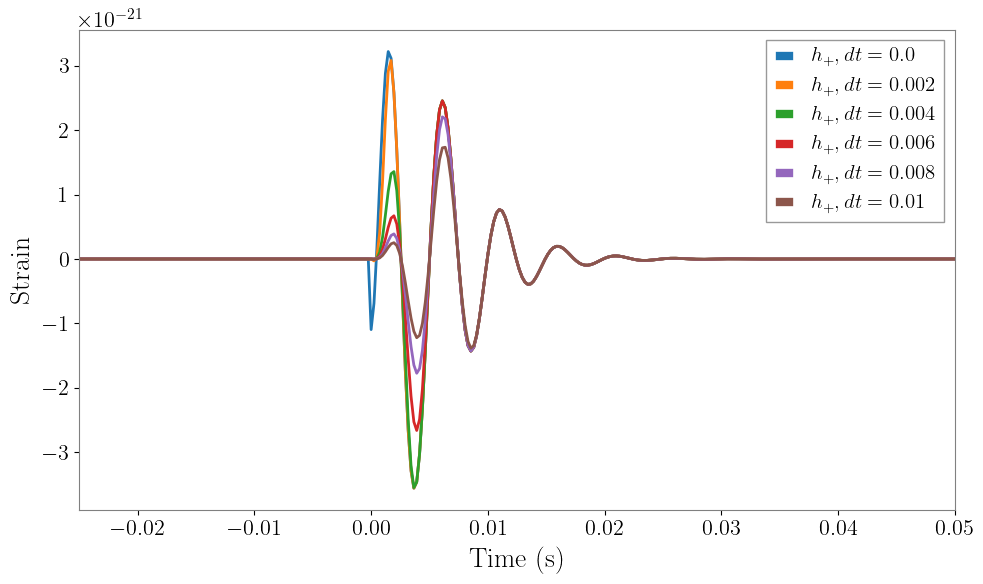

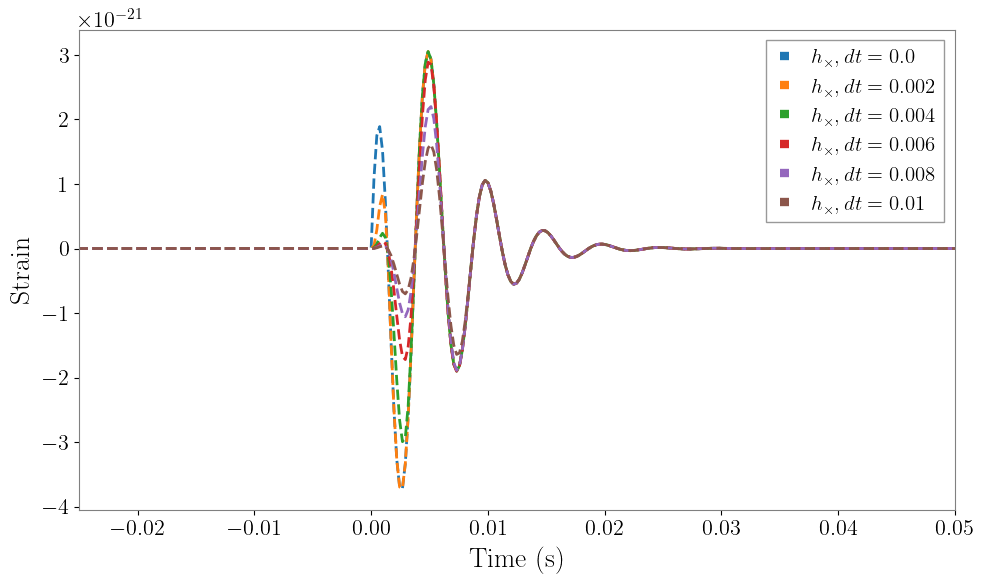

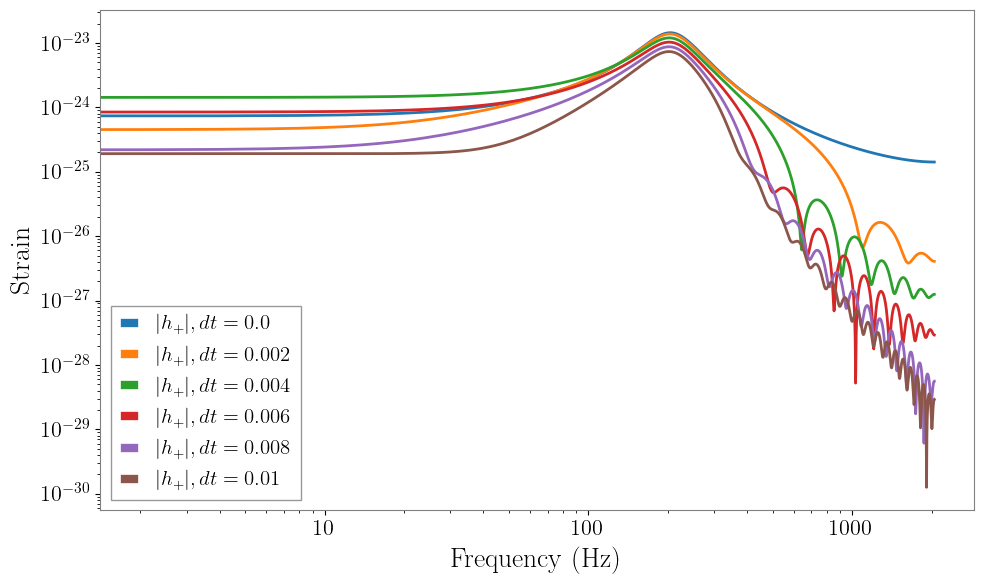

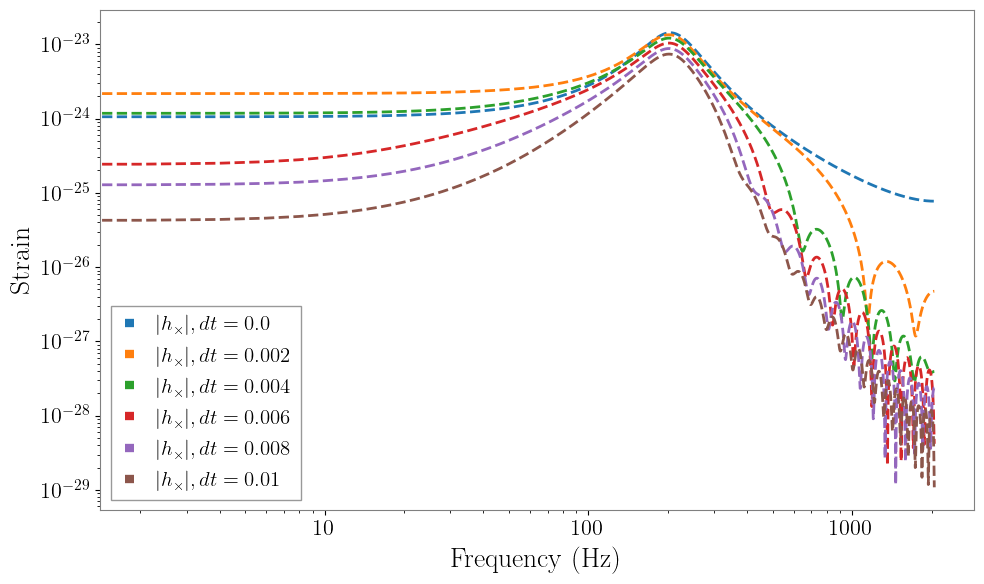

In [6]:
config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam.ini'

signal_roll_on_duration_list = np.arange(0.0, 0.0101, 0.002).tolist()
get_ringdown_waveform_from_config(config_path, signal_roll_on_duration_list=signal_roll_on_duration_list)

14:46 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, overtone parameterization
14:46 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_OTparam_v3
14:46 bilby INFO    : mode_number : two_mode
14:46 bilby INFO    : parameterization : OT
14:46 bilby INFO    : one_mode : False
14:46 bilby INFO    : analysis_one_mode : False
14:46 bilby INFO    : minimum_frequency : 20
14:46 bilby INFO    : maximum_frequency : 512
14:46 bilby INFO    : duration : 0.5
14:46 bilby INFO    : sampling frequency : 4096.0
14:46 bilby INFO    : trigger time : 0.0
14:46 bilby INFO    : start time : -0.25
14:46 bilby INFO    : signal_roll_on_duration : 0.0
14:46 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
14:46 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
14:46 bil

--------------------------------
SNR of only plus mode : [32.29963484 51.73290466  3.1075553 ]
network SNR of only plus mode : 61.0673131460579
SNR of only cross mode : [49.96463076 47.96544482 38.32139884]
network SNR of only cross mode : 79.15603472122119
--------------------------------

--------------------------------
SNR : [59.55101195 70.6194975  38.44227161]
network SNR : 100.05620770005976
--------------------------------
--------------------------------
SNR of only plus mode : [31.48654008 50.43060655  3.02781284]
network SNR of only plus mode : 59.52995828881523
SNR of only cross mode : [48.33698186 46.40292145 36.99090807]
network SNR of only cross mode : 76.53771759269584
--------------------------------

--------------------------------
SNR : [58.23849033 69.24348265 37.05726584]
network SNR : 97.77332252250234
--------------------------------
--------------------------------
SNR of only plus mode : [28.52090005 45.68067133  2.74223445]
network SNR of only plus mode : 53.

14:46 bilby INFO    :   phi2 = 0.0
14:46 bilby INFO    :   ra = 0.0
14:46 bilby INFO    :   dec = 0.0
14:46 bilby INFO    :   psi = 0.0
14:46 bilby INFO    :   geocent_time = 0.0
14:46 bilby INFO    :   window_alpha = 0.1
14:46 bilby INFO    :   signal_roll_on_duration = 0.008
14:46 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
14:46 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
14:46 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_distance'
14:46 bilby INFO    : Injected signal in L1:
14:46 bilby INFO    :   optimal SNR = 46.88
14:46 bilby INFO    :   matched filter SNR = 45.58-0.58j
14:46 bilby INFO    :   A = 0.2965
14:46 bilby INFO    :   alpha = 0.00029552945685847607
14:46 bilby INFO    :   f1 = 201.23779332666524
14:46 bilby INFO    :   tau1 = -0.0033219623034593474
14:46 bilby INFO    :   f2 = 180.55156366778309
14:46 bilby INFO    :   tau2 = -0.0033219623034593474
14:46 bilby INFO 

--------------------------------
SNR of only plus mode : [21.39112592 34.26122565  2.0556852 ]
network SNR of only plus mode : 40.4430178468144
SNR of only cross mode : [33.30133328 31.96887958 25.5067892 ]
network SNR of only cross mode : 52.740727666045665
--------------------------------

--------------------------------
SNR : [39.59466158 46.87912486 25.58766064]
network SNR : 66.48396761797078
--------------------------------
--------------------------------
SNR of only plus mode : [17.99453527 28.82105579  1.72729431]
network SNR of only plus mode : 34.021171379018924
SNR of only cross mode : [28.03839593 26.916523   21.45076242]
network SNR of only cross mode : 44.393536302715596
--------------------------------

--------------------------------
SNR : [33.30505892 39.42122678 21.52130161]
network SNR : 55.914456929911225
--------------------------------


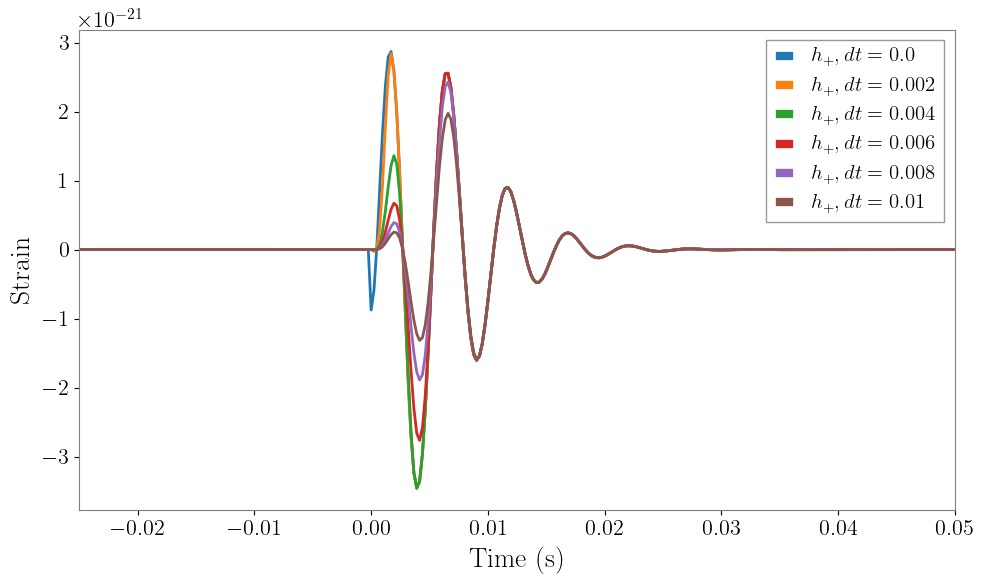

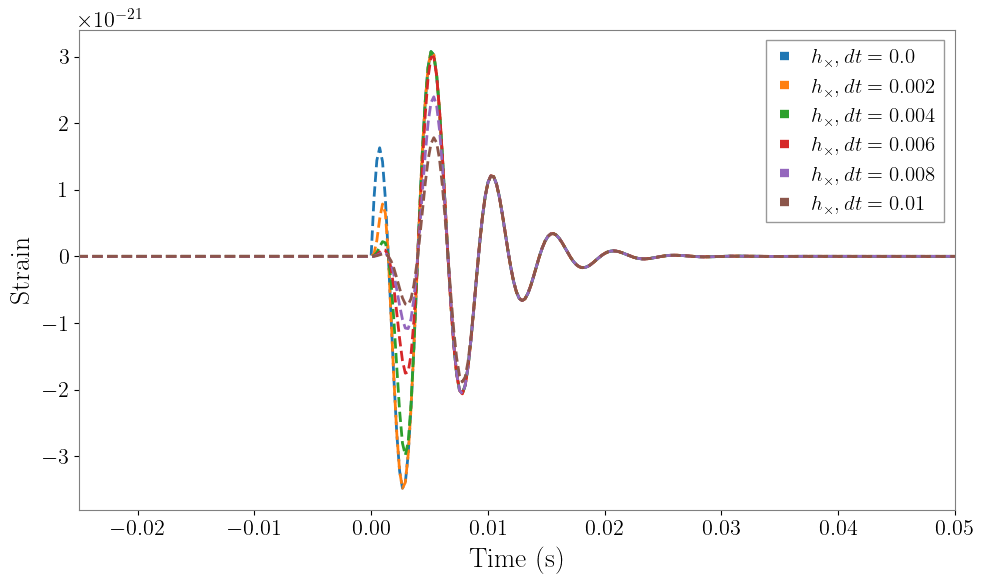

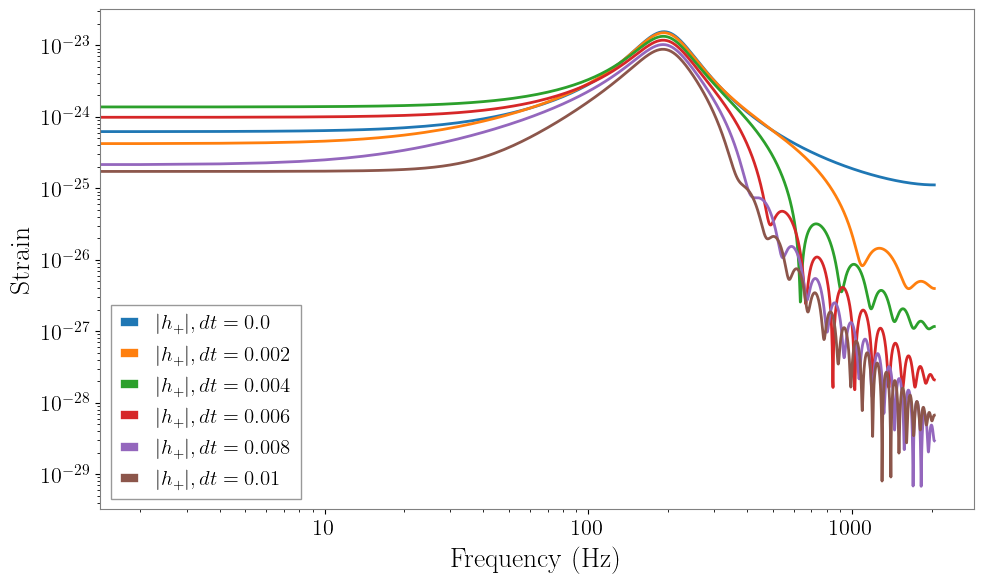

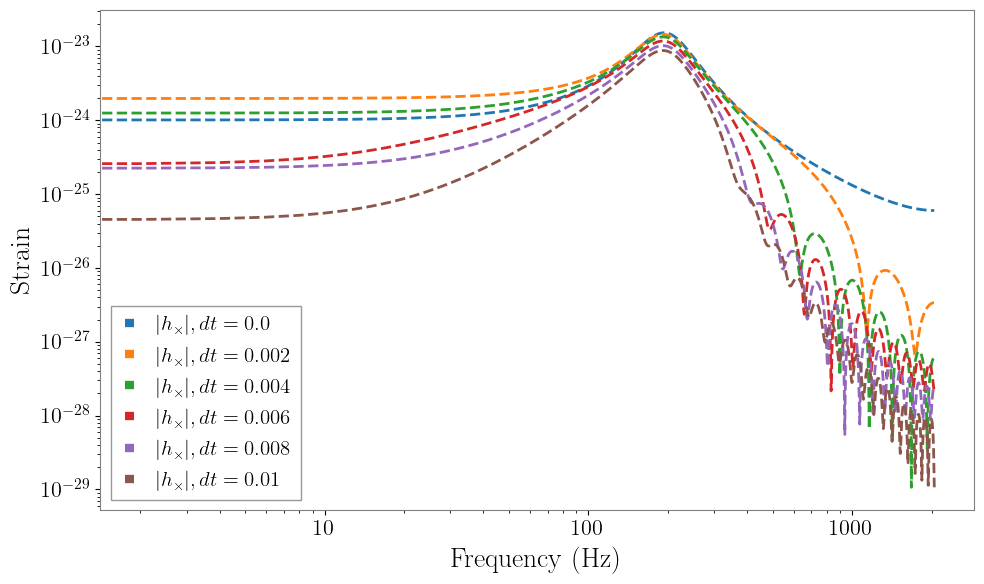

In [8]:
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam.ini'
config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam.ini'

signal_roll_on_duration_list = np.arange(0.0, 0.0101, 0.002).tolist()
get_ringdown_waveform_from_config(config_path, signal_roll_on_duration_list=signal_roll_on_duration_list)

17:06 bilby INFO    : shift imaginary part of w to 220 with spin0, dw/w0.1, snr100, overtone parameterization
17:06 bilby INFO    : event_name : shiftIm_to_220_dw0.1w1_snr100_OTparam_v3
17:06 bilby INFO    : mode_number : two_mode
17:06 bilby INFO    : parameterization : OT
17:06 bilby INFO    : one_mode : False
17:06 bilby INFO    : analysis_one_mode : False
17:06 bilby INFO    : minimum_frequency : 20
17:06 bilby INFO    : maximum_frequency : 512
17:06 bilby INFO    : duration : 0.5
17:06 bilby INFO    : sampling frequency : 4096.0
17:06 bilby INFO    : trigger time : 0.0
17:06 bilby INFO    : start time : -0.25
17:06 bilby INFO    : signal_roll_on_duration : 0.0
17:06 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
17:06 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
17:0

--------------------------------
SNR of only plus mode : [32.30595857 51.7430331   3.1360668 ]
network SNR of only plus mode : 61.080695386879576
SNR of only cross mode : [49.83976876 47.84557881 38.57039691]
network SNR of only cross mode : 79.1257068169124
--------------------------------

--------------------------------
SNR : [59.47519821 70.57857264 38.68959388]
network SNR : 100.07756387909093
--------------------------------
--------------------------------
SNR of only plus mode : [32.02800027 51.29783952  3.10508488]
network SNR of only plus mode : 60.554955975313796
SNR of only cross mode : [49.07182131 47.10835848 37.93026048]
network SNR of only cross mode : 77.88418161398094
--------------------------------

--------------------------------
SNR : [58.4046679  69.39535238 38.08687187]
network SNR : 98.37392933604256
--------------------------------
--------------------------------
SNR of only plus mode : [31.06018123 49.74772632  3.01270556]
network SNR of only plus mode : 5

17:06 bilby INFO    :   dec = 0.0
17:06 bilby INFO    :   psi = 0.0
17:06 bilby INFO    :   geocent_time = 0.0
17:06 bilby INFO    :   window_alpha = 0.1
17:06 bilby INFO    :   signal_roll_on_duration = 0.004
17:06 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.get_each_overtone
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
17:06 bilby INFO    : signal_roll_on_duration : 0.005
17:06 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
17:06 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
17:06 bilby INFO    : Generation of spin parameters failed with message 'spin_1z'
17:06 bilby INFO    : Generation of source frame parameters failed with message 'luminosity_dis

--------------------------------
SNR of only plus mode : [27.3795342  43.85259584  2.6549611 ]
network SNR of only plus mode : 51.7661846486882
SNR of only cross mode : [42.81340875 41.10035767 33.08718569]
network SNR of only cross mode : 67.9484306375104
--------------------------------

--------------------------------
SNR : [50.47390013 59.65279316 33.2307569 ]
network SNR : 84.91380058863739
--------------------------------
--------------------------------
SNR of only plus mode : [25.3871265  40.66144406  2.4633573 ]
network SNR of only plus mode : 47.99924326452486
SNR of only cross mode : [39.41236533 37.83539687 30.47620481]
network SNR of only cross mode : 62.55917883914148
--------------------------------

--------------------------------
SNR : [46.93927758 55.617064   30.56847131]
network SNR : 78.9365886345395
--------------------------------


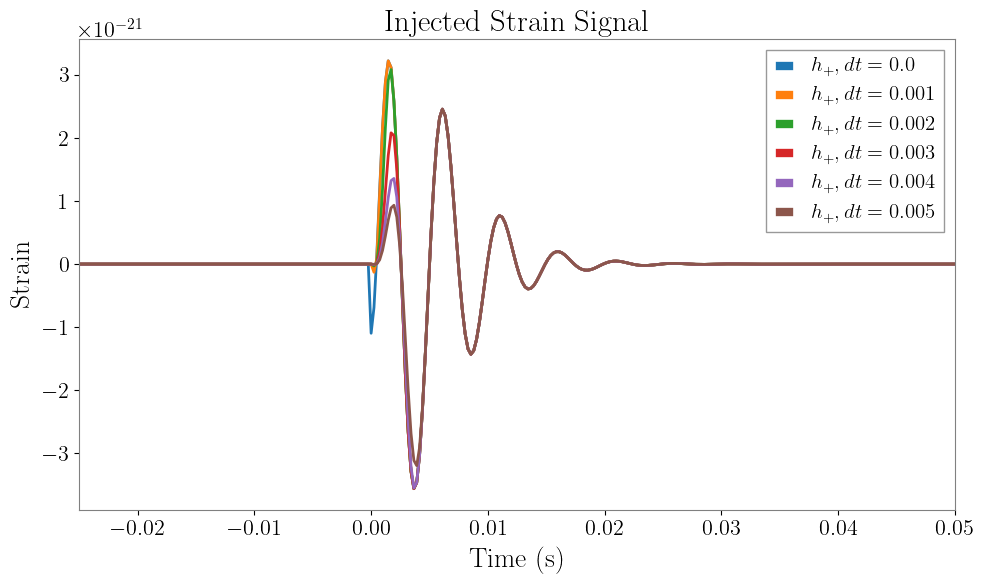

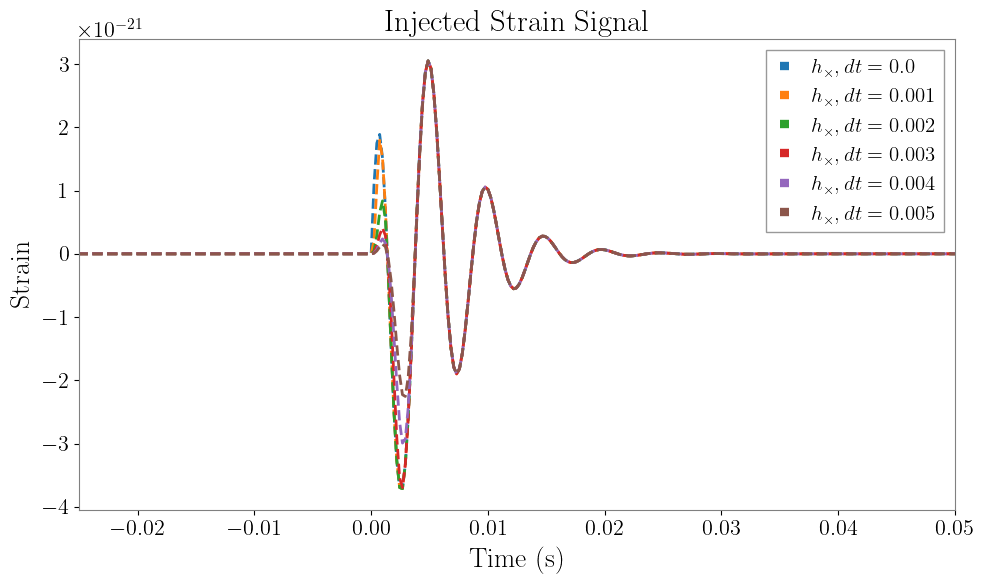

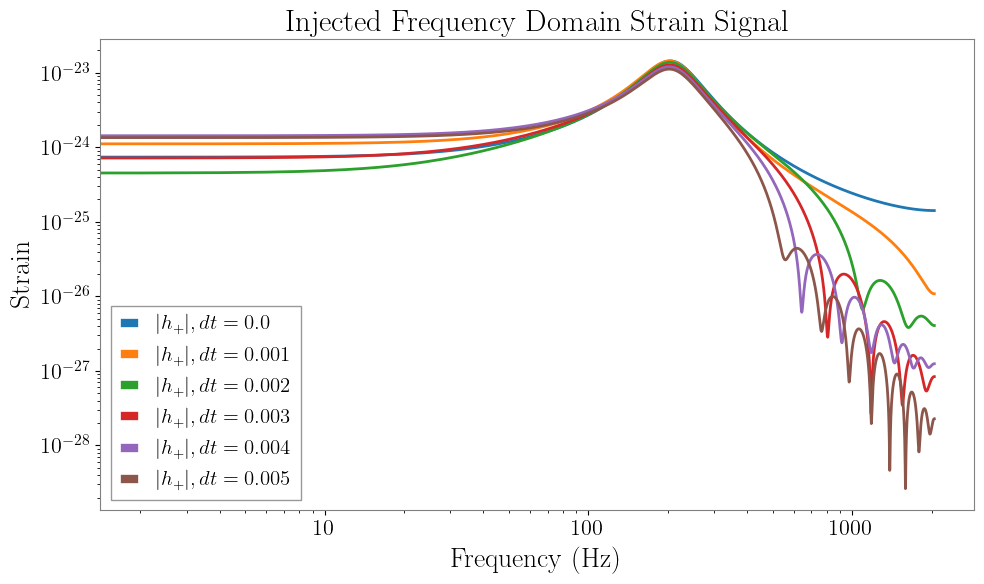

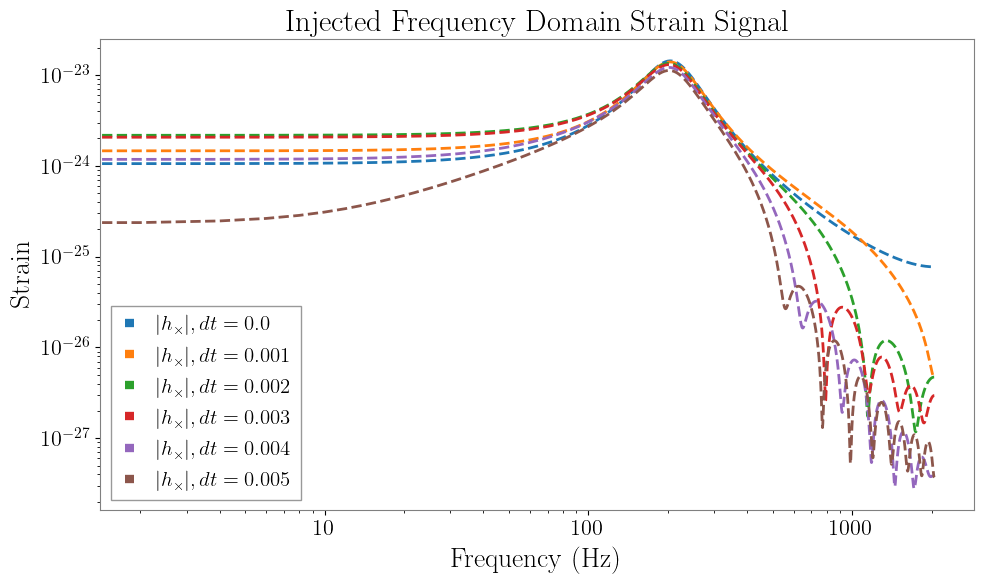

In [17]:
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_DSparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_DSparam.ini'

config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftIm_to_220_dw0.001w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.1w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.01w1_snr100_OTparam.ini'
# config_path = '/Users/hayato/research/ringdown/injection_analysis/config/shiftRe_to_220_dw0.001w1_snr100_OTparam.ini'

signal_roll_on_duration_list = np.arange(0.0, 0.0051, 0.001).tolist()
get_ringdown_waveform_from_config(config_path, signal_roll_on_duration_list=signal_roll_on_duration_list)